In [57]:
import pandas as pd
import numpy as np
import seaborn as sns

In [58]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [59]:
df = sns.load_dataset('titanic')

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [61]:
X = df['sibsp']
y = df['survived']

In [62]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [63]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train.values.reshape(-1,1),y_train)

LogisticRegression()

In [64]:
preds = model.predict(X_test.values.reshape(-1,1))
preds

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0])

In [65]:
probs = model.predict_proba(X_test.values.reshape(-1,1))
probs[1]

array([0.61241376, 0.38758624])

In [66]:
import numpy as np

x_min, x_max = X.min()- 1, X.max() + 1
x_range = np.linspace(x_min, x_max, 300).reshape(-1, 1)

probs = model.predict_proba(x_range)[:, 1]


In [67]:
boundary_index = np.argmin(np.abs(probs - 0.5))
decision_boundary = x_range[boundary_index][0]

print("Decision boundary (sibsp):", decision_boundary)


Decision boundary (sibsp): -1.0


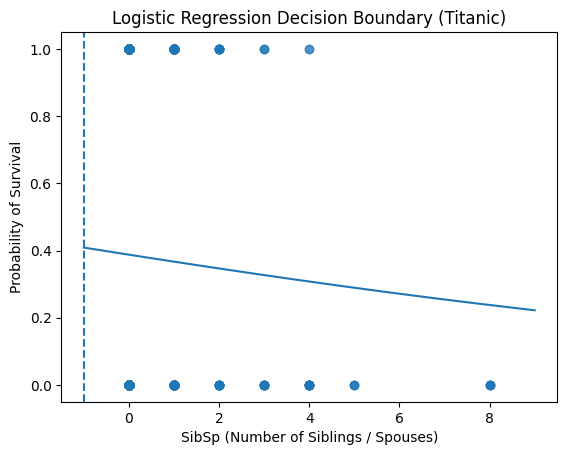

In [68]:
import matplotlib.pyplot as plt

plt.figure()

# Actual data
plt.scatter(X, y, alpha=0.4)

# Sigmoid curve
plt.plot(x_range, probs)

# Decision boundary (vertical line)
plt.axvline(decision_boundary, linestyle="--")

plt.xlabel("SibSp (Number of Siblings / Spouses)")
plt.ylabel("Probability of Survival")
plt.title("Logistic Regression Decision Boundary (Titanic)")
plt.show()
